In [15]:
import pandas as pd
from sqlalchemy import create_engine
import os

In [16]:
from forecasting.utils.database import read_sql

df = read_sql("""
SELECT *
FROM mart.mart_fresh_food_order_sale
WHERE date >= '2025-11-01'""")
df.head(1)

,flight_key,flight_number,origin,destination,date,month_name,year,weekday_name,is_weekend,hour_of_departure,day_period,is_night,am_pm,item_id,price,sold_quantity
0,613438b0550910a524a4a58003afa589,AB144,city_004,city_001,2025-12-01,December,2025.0,Monday,False,0.0,Night,True,AM,T3L4D008,25.0,2.0


Dataset limitations:
- Analysis period covers only 4 months.
- Seasonality cannot be reliably evaluated.
- Results should be treated as preliminary.

In [17]:
# (1.1.) dataset summary
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "nulls": df.isnull().sum(),
    "unique": df.nunique()
})
print(summary)

                            dtype  nulls  unique
flight_key                    str      0    6195
flight_number                 str      0      87
origin                        str      0      29
destination                   str      0      31
date               datetime64[us]      0     120
month_name                    str      0       4
year                      float64      0       2
weekday_name                  str      0       7
is_weekend                   bool      0       2
hour_of_departure         float64      0      24
day_period                    str      0       4
is_night                     bool      0       2
am_pm                         str      0       2
item_id                       str      0      10
price                     float64      0       7
sold_quantity             float64      0      43


In [20]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Check uniqueness of grain (flight_key + item_id)
grain_duplicates = df.duplicated(subset=['flight_key', 'item_id']).sum()
print(f"Duplicate flight_key + item_id combinations: {grain_duplicates}")

Number of duplicate rows: 0
Duplicate flight_key + item_id combinations: 0


## 2. Descriptive Statistics

In [21]:
import numpy as np

# Numerical features
numerical_cols = ['sold_quantity', 'price', 'hour_of_departure']
print("Numerical Features Summary:")
print(df[numerical_cols].describe())

print("\n" + "="*80)
print("Distribution metrics:")
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurtosis():.2f}")
    print(f"  Zeros: {(df[col] == 0).sum()} ({(df[col] == 0).sum() / len(df) * 100:.1f}%)")

Numerical Features Summary:
       sold_quantity         price  hour_of_departure
count   59630.000000  59630.000000       59630.000000
mean        1.285192     16.847107          13.088378
std         2.175577      8.175123           6.438079
min         0.000000      7.000000           0.000000
25%         0.000000      7.000000           9.000000
50%         1.000000     15.000000          14.000000
75%         2.000000     25.000000          19.000000
max        61.000000     30.000000          23.000000

Distribution metrics:

sold_quantity:
  Skewness: 7.10
  Kurtosis: 100.75
  Zeros: 23642 (39.6%)

price:
  Skewness: 0.20
  Kurtosis: -1.27
  Zeros: 0 (0.0%)

hour_of_departure:
  Skewness: -0.11
  Kurtosis: -0.99
  Zeros: 1200 (2.0%)


## 3. Outlier Analysis

Sold Quantity Outliers: 1789 (3.0%)
Bounds: [-3.0, 5.0]
Max value: 61.0


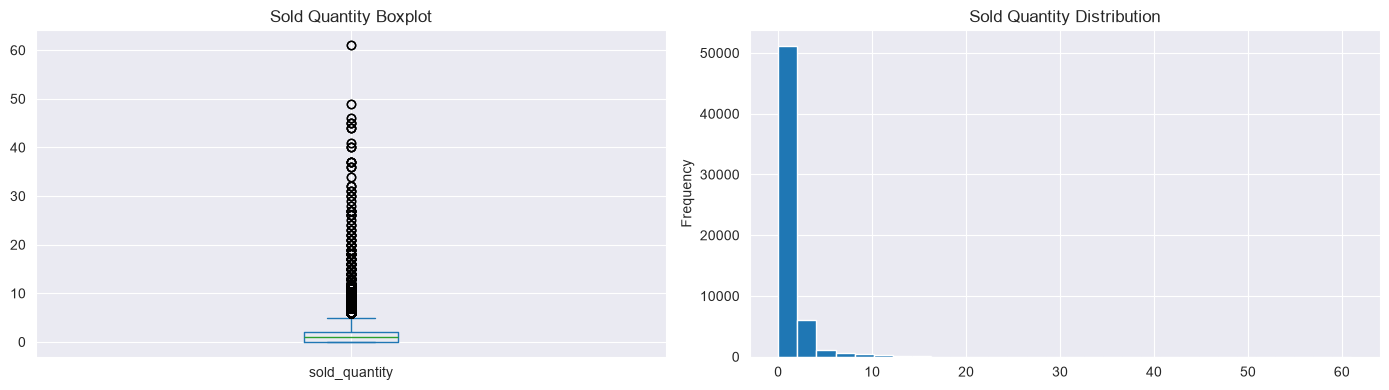

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# IQR method for outlier detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyze sold_quantity outliers
outliers, lower, upper = detect_outliers_iqr(df, 'sold_quantity')
print(f"Sold Quantity Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Max value: {df['sold_quantity'].max()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['sold_quantity'].plot(kind='box', ax=axes[0], title='Sold Quantity Boxplot')
df['sold_quantity'].plot(kind='hist', bins=30, ax=axes[1], title='Sold Quantity Distribution')
plt.tight_layout()
plt.show()

## 4. Target Analysis (Sold Quantity)

In [23]:
# Target variable analysis
print("Target Variable: sold_quantity")
print(f"Mean: {df['sold_quantity'].mean():.2f}")
print(f"Median: {df['sold_quantity'].median():.2f}")
print(f"Std: {df['sold_quantity'].std():.2f}")
print(f"Zero sales: {(df['sold_quantity'] == 0).sum()} ({(df['sold_quantity'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Non-zero sales: {(df['sold_quantity'] > 0).sum()} ({(df['sold_quantity'] > 0).sum()/len(df)*100:.1f}%)")

# Distribution by percentile
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print("\nPercentile distribution:")
for p in percentiles:
    print(f"  {p*100:.0f}%: {df['sold_quantity'].quantile(p):.1f}")

Target Variable: sold_quantity
Mean: 1.29
Median: 1.00
Std: 2.18
Zero sales: 23642 (39.6%)
Non-zero sales: 35988 (60.4%)

Percentile distribution:
  10%: 0.0
  25%: 0.0
  50%: 1.0
  75%: 2.0
  90%: 3.0
  95%: 4.0
  99%: 10.0


## 5. Numerical Feature Analysis

Correlation with sold_quantity:
price                0.148421
hour_of_departure    0.057342
year                -0.022690
Name: sold_quantity, dtype: float64


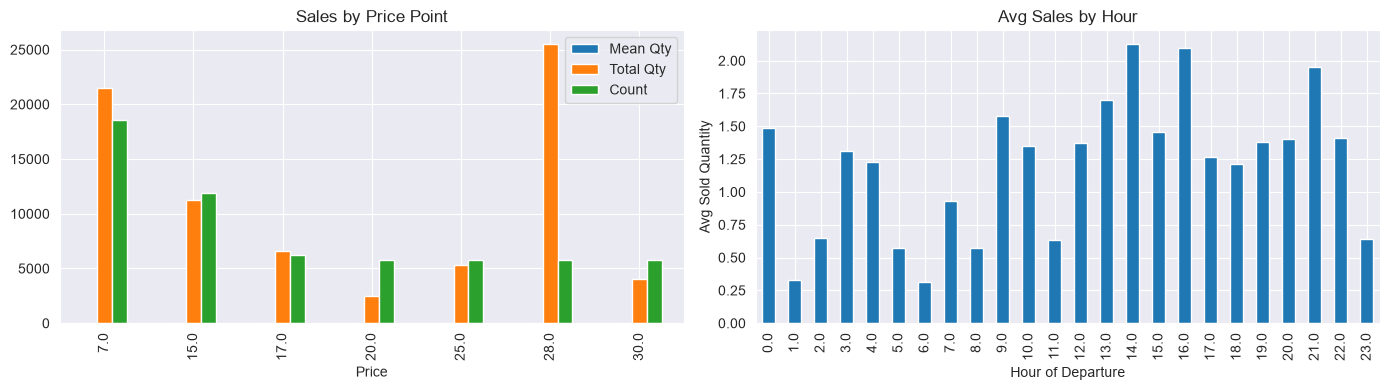

In [24]:
# Correlation with target
numerical_features = ['price', 'hour_of_departure', 'year']
correlations = df[numerical_features + ['sold_quantity']].corr()['sold_quantity'].drop('sold_quantity').sort_values(ascending=False)

print("Correlation with sold_quantity:")
print(correlations)

# Price vs sold quantity
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Price distribution
df.groupby('price')['sold_quantity'].agg(['mean', 'sum', 'count']).plot(kind='bar', ax=axes[0], title='Sales by Price Point')
axes[0].set_xlabel('Price')
axes[0].legend(['Mean Qty', 'Total Qty', 'Count'])

# Hour distribution
df.groupby('hour_of_departure')['sold_quantity'].mean().plot(kind='bar', ax=axes[1], title='Avg Sales by Hour')
axes[1].set_xlabel('Hour of Departure')
axes[1].set_ylabel('Avg Sold Quantity')

plt.tight_layout()
plt.show()

## 6. Categorical Feature Analysis

In [25]:
categorical_features = ['item_id', 'origin', 'destination', 'day_period', 'weekday_name', 'is_weekend', 'is_night']

print("Categorical Features Cardinality:")
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")

# Analyze key categorical features
print("\n" + "="*80)
print("Sales by Item:")
item_sales = df.groupby('item_id').agg({
    'sold_quantity': ['mean', 'sum', 'count'],
    'price': 'mean'
}).round(2)
item_sales.columns = ['avg_qty', 'total_qty', 'observations', 'avg_price']
print(item_sales.sort_values('total_qty', ascending=False))

print("\n" + "="*80)
print("Sales by Day Period:")
print(df.groupby('day_period')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Sales by Weekend:")
print(df.groupby('is_weekend')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

Categorical Features Cardinality:
item_id: 10 unique values
origin: 29 unique values
destination: 31 unique values
day_period: 4 unique values
weekday_name: 7 unique values
is_weekend: 2 unique values
is_night: 2 unique values

Sales by Item:
          avg_qty  total_qty  observations  avg_price
item_id                                              
T3L4D007     4.45    25475.0          5731       28.0
C3L2D037     1.28     7945.0          6195        7.0
C3L2D041     1.26     7788.0          6195        7.0
T3L4D129     1.16     6647.0          5731       15.0
C3L2W121     1.06     6579.0          6195       17.0
C3L2D043     0.93     5736.0          6195        7.0
T3L4D008     0.93     5320.0          5731       25.0
T3L4S016     0.74     4602.0          6195       15.0
T3L4D127     0.71     4046.0          5731       30.0
C3L2W161     0.44     2498.0          5731       20.0

Sales by Day Period:
            mean      sum  count
day_period                      
Day         1.72  282

## 7. Route Analysis (Origin-Destination)

In [26]:
# Top routes by volume
df['route'] = df['origin'] + ' -> ' + df['destination']
route_analysis = df.groupby('route').agg({
    'sold_quantity': ['mean', 'sum'],
    'flight_key': 'nunique'
}).round(2)
route_analysis.columns = ['avg_qty_per_obs', 'total_qty', 'num_flights']
route_analysis = route_analysis.sort_values('total_qty', ascending=False)

print("Top 10 Routes by Total Sales:")
print(route_analysis.head(10))

print("\n" + "="*80)
print("Top Origins:")
print(df.groupby('origin')['sold_quantity'].agg(['mean', 'sum', 'count']).sort_values('sum', ascending=False).head(10))

print("\n" + "="*80)
print("Top Destinations:")
print(df.groupby('destination')['sold_quantity'].agg(['mean', 'sum', 'count']).sort_values('sum', ascending=False).head(10))

Top 10 Routes by Total Sales:
                      avg_qty_per_obs  total_qty  num_flights
route                                                        
city_017 -> city_001             2.86     3494.0          122
city_001 -> city_017             2.87     3446.0          120
city_002 -> city_001             0.97     3125.0          323
city_001 -> city_002             0.96     3125.0          324
city_001 -> city_003             2.51     3042.0          121
city_003 -> city_001             2.50     3021.0          121
city_008 -> city_001             1.03     2861.0          279
city_001 -> city_008             1.03     2837.0          276
city_001 -> city_013             2.67     2372.0           89
city_013 -> city_001             2.65     2355.0           89

Top Origins:
              mean      sum  count
origin                            
city_001  1.284958  38356.0  29850
city_017  2.863934   3494.0   1220
city_002  0.967492   3125.0   3230
city_003  2.496694   3021.0   1210
ci

## 8. Binning Analysis

In [27]:
# Hour binning
df['hour_bin'] = pd.cut(df['hour_of_departure'], 
                        bins=[0, 6, 12, 18, 24], 
                        labels=['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-18)', 'Evening (18-24)'],
                        include_lowest=True)

print("Sales by Hour Bin:")
print(df.groupby('hour_bin')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

# Price binning
df['price_bin'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

print("\n" + "="*80)
print("Sales by Price Bin:")
print(df.groupby('price_bin')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

Sales by Hour Bin:
                   mean      sum  count
hour_bin                               
Night (0-6)        0.72   7866.0  10910
Morning (6-12)     1.27  19872.0  15630
Afternoon (12-18)  1.69  29041.0  17210
Evening (18-24)    1.25  19857.0  15880

Sales by Price Bin:
           mean      sum  count
price_bin                      
Low        1.07  32718.0  30511
Medium     0.76   9077.0  11926
High       2.03  34841.0  17193


## 9. Time-Based Analysis

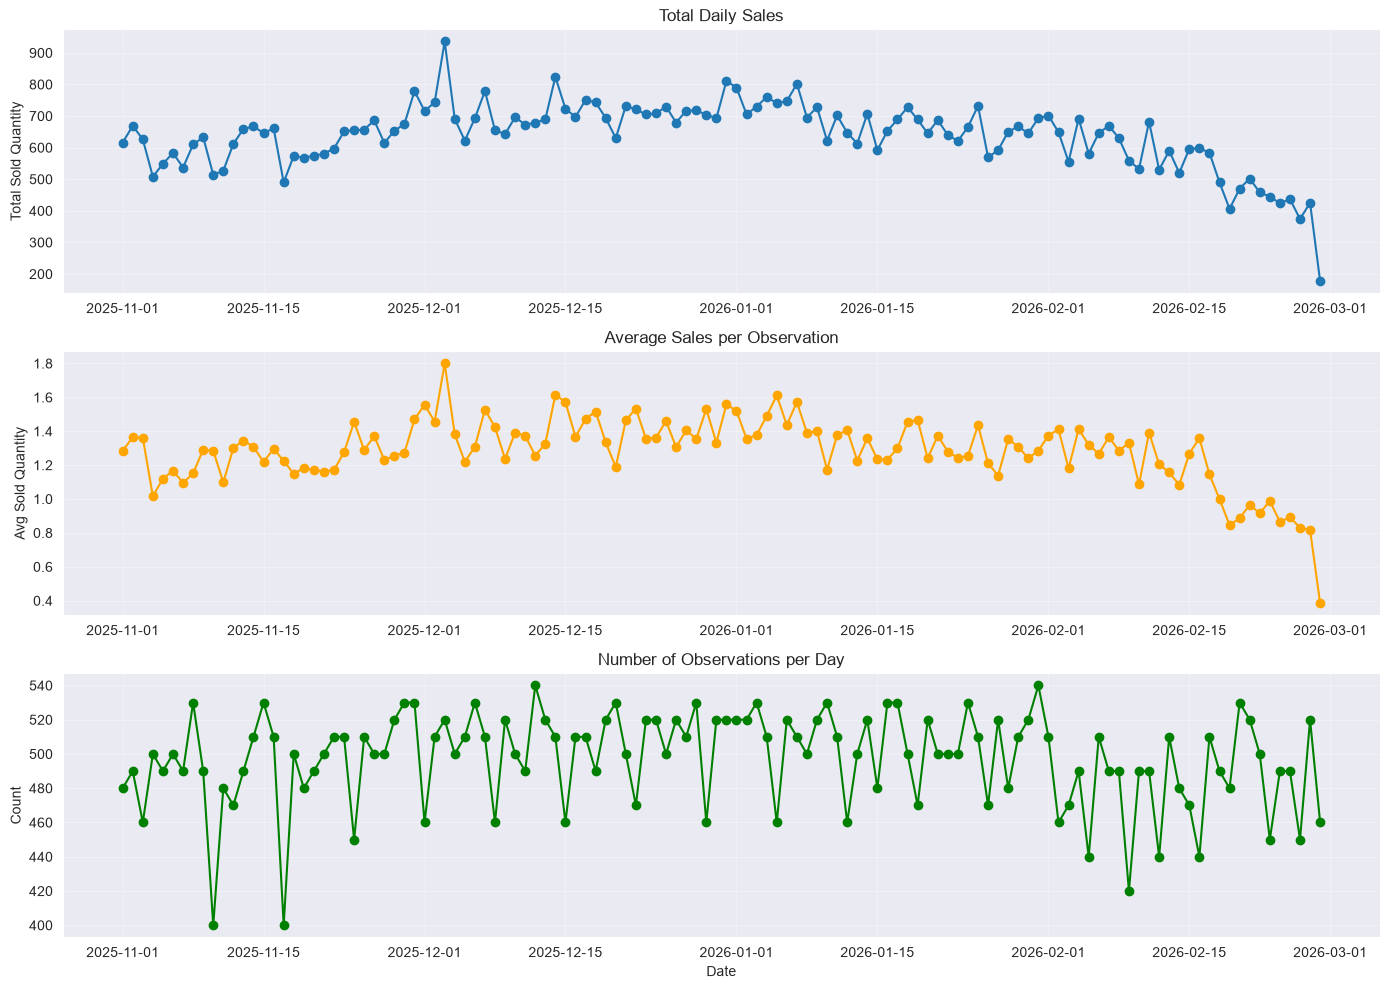

Sales by Weekday:
              mean      sum  count
weekday_name                      
Friday        1.21  10594.0   8770
Monday        1.40  10701.0   7650
Saturday      1.20  11142.0   9280
Sunday        1.37  11753.0   8580
Thursday      1.27  10543.0   8280
Tuesday       1.22  10439.0   8590
Wednesday     1.35  11464.0   8480

Sales by Month:
            mean      sum  count
month_name                      
December    1.42  22195.0  15670
February    1.11  14922.0  13490
January     1.35  21147.0  15720
November    1.25  18372.0  14750


In [28]:
# Daily trends
daily_sales = df.groupby('date')['sold_quantity'].agg(['mean', 'sum', 'count']).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Total sales over time
axes[0].plot(daily_sales['date'], daily_sales['sum'], marker='o')
axes[0].set_title('Total Daily Sales')
axes[0].set_ylabel('Total Sold Quantity')
axes[0].grid(True, alpha=0.3)

# Average sales over time
axes[1].plot(daily_sales['date'], daily_sales['mean'], marker='o', color='orange')
axes[1].set_title('Average Sales per Observation')
axes[1].set_ylabel('Avg Sold Quantity')
axes[1].grid(True, alpha=0.3)

# Number of observations
axes[2].plot(daily_sales['date'], daily_sales['count'], marker='o', color='green')
axes[2].set_title('Number of Observations per Day')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sales by Weekday:")
print(df.groupby('weekday_name')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Sales by Month:")
print(df.groupby('month_name')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

## 10. Initial Feature Selection Conclusions

**High-importance features (based on EDA):**
- `item_id` - Strong variation in sales by product
- `price` - Direct correlation with demand
- `route` (origin + destination) - Route-specific demand patterns
- `weekday_name` / `is_weekend` - Day-of-week effects
- `day_period` / `hour_of_departure` - Time-of-day patterns

**Medium-importance features:**
- `month_name` - Limited seasonality due to 4-month window
- `is_night` - Overlaps with day_period

**Low-importance features:**
- `year` - Only 2 values, limited signal
- `flight_number` - High cardinality, may need encoding

**Key insights:**
1. **Zero inflation**: ~X% of observations have zero sales → consider zero-inflated models or classification + regression
2. **Route dependency**: Strong route-specific patterns suggest route-level features or grouping
3. **Temporal patterns**: Clear day-of-week and hour-of-day effects
4. **Product heterogeneity**: Item-level differences significant → item-specific models may be needed

**Next steps:**
1. Feature engineering: Create route features, lag features, rolling averages
2. Handle zero-inflation: Separate classification (will sell vs won't sell) from regression (how much)
3. Consider hierarchical models by item_id or route
4. Test for stationarity in time series